# Figure S15: Cross–quality-metric correlation of GQI FA bundle-wise quality effects

Figure S15 mirrors Figure S14’s clustered Pearson correlation heatmap, but fixes the microstructural outcome to **GQI_fa** and correlates **image quality metrics** (bundle-wise `qc_effect_size`) with each other across white-matter bundles, using harmonized non-vendorwise pairwise outputs.


In [3]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
  library(scales)
  library(grid)
})

config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file.exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) stop("Could not locate config.json")

config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure_s15_dir <- fs::path(project_root, "figures", "Supplement", "FigureS15")
fs::dir_create(figure_s15_dir, recurse = TRUE)

quality_effect_file <- fs::path(project_root, "data", "quality_effects", "quality_effects_all_outputs.rds")
if (!file.exists(quality_effect_file)) stop("Missing assembled quality-effect file: ", quality_effect_file)

df_quality_all <- readRDS(quality_effect_file)
required_cols <- c("bundle", "metric", "qc_metric", "source", "output_type", "qc_effect_size")
missing_cols <- setdiff(required_cols, names(df_quality_all))
if (length(missing_cols) > 0) {
  stop("Assembled quality-effect data missing required columns: ", paste(missing_cols, collapse = ", "))
}


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS15/S15_cross_qc_metric_GQI_fa_quality_effect_correlation_clustered.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS15/S15_cross_qc_metric_GQI_fa_quality_effect_correlation_clustered.png



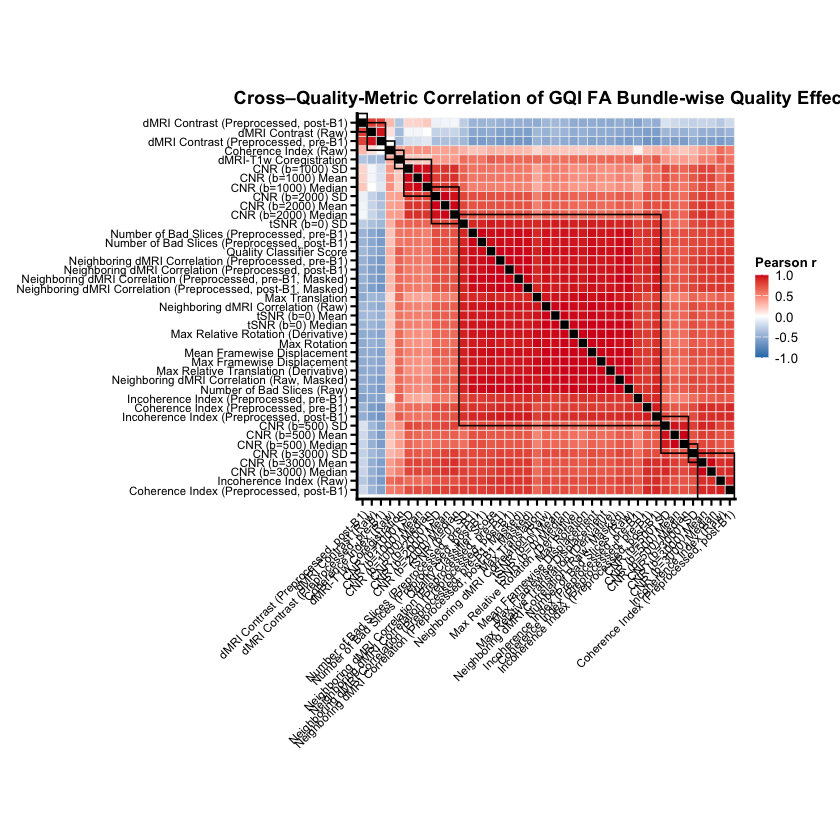

In [4]:
metric_target <- "GQI_fa"

cnr_shell_label <- function(shell_id) {
  switch(
    shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

format_iqm_label <- function(iqm) {
  if (iqm == "qc_prediction") return("Quality Classifier Score")
  if (iqm == "t1_dice_distance") return("dMRI-T1w Coregistration")
  if (iqm %in% c("mean_fd", "max_fd", "max_rotation", "max_translation", "max_rel_rotation", "max_rel_translation")) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    return(paste(cnr_shell_label(shell_id), stat_label))
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifier_parts <- character(0)
  if (nzchar(prefix)) {
    q <- prefix %>%
      str_replace("Preprocessed \\(post-B1\\)", "Preprocessed, post-B1") %>%
      str_replace("Preprocessed \\(pre-B1\\)", "Preprocessed, pre-B1")
    qualifier_parts <- c(qualifier_parts, q)
  }
  if (is_masked) qualifier_parts <- c(qualifier_parts, "Masked")
  if (length(qualifier_parts) > 0) {
    paste0(base_label, " (", paste(qualifier_parts, collapse = ", "), ")")
  } else {
    base_label
  }
}

df_qc <- df_quality_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    source == "harmonized",
    metric == metric_target,
    qc_metric != "no_quality",
    !is.na(bundle),
    !is.na(qc_effect_size)
  ) %>%
  transmute(
    bundle = as.character(bundle),
    qc_metric = as.character(qc_metric),
    qc_effect_size = as.numeric(qc_effect_size)
  )

if (nrow(df_qc) == 0) {
  stop("No rows for Figure S15 (GQI_fa quality effects).")
}

wide_effects <- df_qc %>%
  distinct(bundle, qc_metric, qc_effect_size) %>%
  pivot_wider(names_from = qc_metric, values_from = qc_effect_size)

qc_cols <- setdiff(names(wide_effects), "bundle")
if (length(qc_cols) < 2) {
  stop("Need at least two quality metrics with data to compute the correlation heatmap.")
}

mat <- wide_effects %>%
  select(all_of(qc_cols)) %>%
  as.matrix()

cor_mat <- cor(mat, method = "pearson", use = "pairwise.complete.obs")

dist_mat <- as.dist(1 - cor_mat)
hc <- hclust(dist_mat, method = "average")
qc_order <- colnames(cor_mat)[hc$order]

label_map <- setNames(vapply(qc_order, format_iqm_label, character(1)), qc_order)

heat_df <- as.data.frame(as.table(cor_mat), stringsAsFactors = FALSE) %>%
  rename(qc_y = Var1, qc_x = Var2, rho = Freq) %>%
  mutate(
    is_diag = qc_x == qc_y,
    qc_x = factor(qc_x, levels = qc_order),
    qc_y = factor(qc_y, levels = rev(qc_order))
  )

k_clusters <- min(10, length(qc_order))
cluster_assign <- cutree(hc, k = k_clusters)

cluster_df <- tibble(
  qc_metric = names(cluster_assign),
  cluster = unname(cluster_assign),
  x = match(names(cluster_assign), qc_order)
) %>%
  arrange(x)

cluster_bounds <- cluster_df %>%
  group_by(cluster) %>%
  summarise(
    xmin = min(x) - 0.5,
    xmax = max(x) + 0.5,
    .groups = "drop"
  ) %>%
  mutate(
    ymin = length(qc_order) - xmax + 0.5,
    ymax = length(qc_order) - xmin + 1.5
  )

p_s15 <- ggplot() +
  geom_tile(
    data = filter(heat_df, !is_diag),
    aes(x = qc_x, y = qc_y, fill = rho),
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_tile(
    data = filter(heat_df, is_diag),
    aes(x = qc_x, y = qc_y),
    fill = "black",
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_rect(
    data = cluster_bounds,
    aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
    inherit.aes = FALSE,
    fill = NA,
    color = "black",
    linewidth = 0.45
  ) +
  scale_fill_gradient2(
    low = "#2C7BB6",
    mid = "#FFFFFF",
    high = "#D7191C",
    midpoint = 0,
    limits = c(-1, 1),
    breaks = c(-1, -0.5, 0, 0.5, 1),
    oob = squish,
    name = "Pearson r"
  ) +
  scale_x_discrete(labels = label_map[qc_order]) +
  scale_y_discrete(labels = rev(label_map[qc_order])) +
  coord_fixed(clip = "off") +
  labs(
    x = NULL,
    y = NULL,
    title = "Cross–Quality-Metric Correlation of GQI FA Bundle-wise Quality Effects"
  ) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 8,
    axis_text_pt = 8,
    legend_title_pt = 8,
    legend_text_pt = 8,
    base_size_pt = 8
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    panel.grid = element_blank(),
    plot.title = element_text(size = 11, hjust = 0.5),
    legend.key.height = unit(10, "pt"),
    legend.key.width = unit(8, "pt"),
    plot.margin = margin(t = 10, r = 10, b = 10, l = 10)
  )

p_s15

save_plot_outputs(
  plot_obj = p_s15,
  stub = "S15_cross_qc_metric_GQI_fa_quality_effect_correlation_clustered",
  out_dir = figure_s15_dir,
  width_in = 14,
  height_in = 14
)
